# Introduction: The Geometric Intuition"
"Stop thinking in formulas, start thinking in flows."

In traditional calculus, we are taught to solve $\dot{x} = f(x)$ by integrating to find $x(t)$. But for most complex systems, an analytical solution is impossible. Steven Strogatz argues that we should instead look at the Vector Field.

"We think of $t$ as time, $x$ as the position of an imaginary particle moving along the real line, and $\dot{x}$ as the velocity of that particle... The flow is to the right where $f(x) > 0$ and to the left where $f(x) < 0$." — Strogatz 

Fixed Points: The Anchors of Logic
- Attractors (Stable): Points where the flow converges. These represent "memories" or "steady states."
- Repellers (Unstable): Points where the flow pushes the state away. These represent "decision boundaries."

 # The Anatomy of Stability

## What is Stability?
In a dynamical system, a fixed point $x^*$ is stable if the system resists change. If you "nudge" the state slightly away from $x^*$, the physics of the system should force it back.

## Method 1: The Graphical Intuition (The "Velocity" View)
In 1D, $\dot{x} = f(x)$ means the graph of f(x) is a Velocity Map.

**The Nudge:** Imagine a fixed point at $x^*$.
- **Nudge Right ( x > $x^*$): If the graph of f(x) is below the x-axis (negative velocity), the particle is pushed back to the Left toward $x^*$.
- **Nudge Left ( x < $x^*$): If the graph of f(x) is above the x-axis (positive velocity), the particle is pushed back to the Right toward $x^*$.

**The Condition:** 
For the arrows to point "inward" from both sides, the function (x) must cross the x-axis from positive to negative. This is why a negative slope at the fixed point f(x^*) < 0 guarantees stability.

## Method 2: Linear Stability Analysis (The "Eigenvalue" View)
Let (t) = x(t) - $x^*$ be a tiny perturbation. As we derived in our derivations.md:

$$
\dot{u} \approx f'(x^*)u
$$
The solution is $u(t) = u(0)e^{f'(x^*)t}$.
In 1D, the Jacobian Matrix is just the scalar $J = [f'(x^*)]$.
The Eigenvalue $\lambda$ of this Jacobian is simply $f'(x^*)$.The Math of Decay: If $\lambda < 0$, the term $e^{\lambda t}$ represents exponential decay. The "error" $u(t)$ vanishes over time.


# Case Study: The Logistic Equation
 
## The Model
 
The Logistic Equation is defined as:
 
$$\dot{x} = rx \left(1 - \frac{x}{K}\right)$$
 
Setting growth rate $r = 1$ and carrying capacity $K = 1$, we get the simplified form:
 
$$\dot{x} = x(1 - x)$$
 
---
 
## Linear Stability Analysis
 
A small perturbation $u$ away from a fixed point $x^*$ evolves according to:
 
$$\dot{u} = f'(x^*)\, u$$
 
For $x^* = 1$: $\quad f'(1) = -1$
 
Since the slope is **negative**, the perturbation decays. **Prediction: $x = 1$ is a stable attractor.**
 
---
 
## Manual Implementation: The Euler Engine
 
The Euler method is the simplest way to simulate time — take the current position, calculate the velocity, and move a small step in that direction.
 
$$x_{n+1} = x_n + f(x_n)\,\Delta t$$

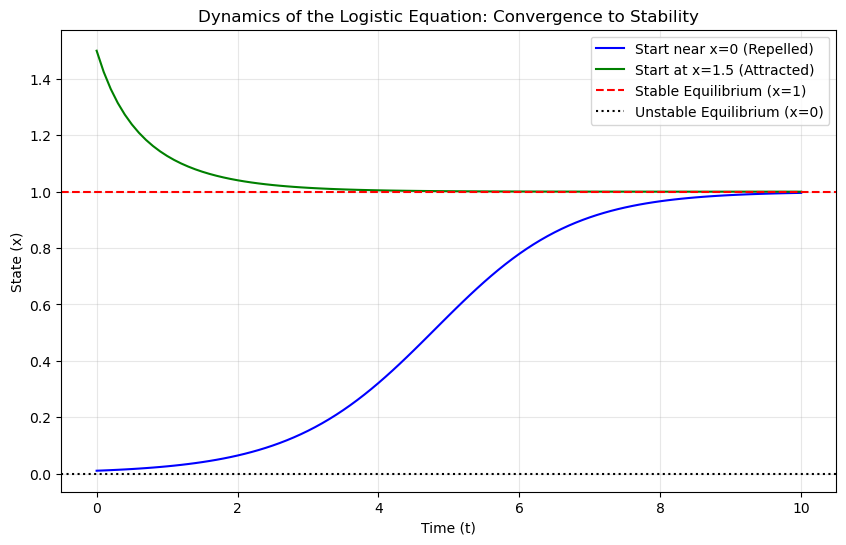

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def logistic_flow(x):
    """The velocity function f(x) = x(1 - x)"""
    return x * (1 - x)

def euler_solve(flow_func, x0, dt, total_time):
    # Calculate total number of steps
    steps = int(total_time / dt)
    
    # Initialize history with the starting point
    x_history = [x0]
    current_x = x0
    
    for i in range(steps):
        # 1. Calculate the velocity (v) at the current_x
        v = flow_func(current_x)
        
        # 2. Update current_x: new_x = old_x + velocity * dt
        current_x = current_x + v * dt
        
        # 3. Append the new state to our history
        x_history.append(current_x)
        
    return np.array(x_history)

# --- Simulation and Visualization ---
x0_unstable = 0.01  # Start near the unstable point x=0
x0_above = 1.5      # Start above the stable point x=1

dt = 0.1
T = 10

traj1 = euler_solve(logistic_flow, x0_unstable, dt, T)
traj2 = euler_solve(logistic_flow, x0_above, dt, T)

# Plotting the "Convergence to Stability"
plt.figure(figsize=(10, 6))
t_axis = np.linspace(0, T, len(traj1))

plt.plot(t_axis, traj1, label="Start near x=0 (Repelled)", color='blue')
plt.plot(t_axis, traj2, label="Start at x=1.5 (Attracted)", color='green')
plt.axhline(1, color='red', linestyle='--', label="Stable Equilibrium (x=1)")
plt.axhline(0, color='black', linestyle=':', label="Unstable Equilibrium (x=0)")

plt.title("Dynamics of the Logistic Equation: Convergence to Stability")
plt.xlabel("Time (t)")
plt.ylabel("State (x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# The Potential Persceptive 
....theory b;ah b;ah

Causal AI Relevance Examples: Stability & Dynamical Systems
 
---
 
## A. Activation Saturation — Tanh Bistability (Deep Learning)
 
### The Model
 
A neuron with Tanh activation in discrete time:
 
$$x_{\text{next}} = \tanh(w \cdot x_{\text{prev}})$$
 
In continuous time, this becomes:
 
$$\dot{x} = -x + \tanh(w \cdot x)$$
 
### Fixed Point Analysis
 
Fixed points occur where $\dot{x} = 0$, i.e., where $x = \tanh(w \cdot x)$.
 
The stability of each fixed point is determined by the **slope** of $f(x) = -x + \tanh(wx)$:
 
$$f'(x) = -1 + w \cdot \text{sech}^2(wx)$$
 
| Condition | Fixed Points | Behaviour |
|---|---|---|
| $w \leq 1$ | Only $x^* = 0$ | Monostable — neuron always off |
| $w > 1$ | $x^* = 0$ (unstable) + $\pm x^*$ (stable) | **Bistable** — neuron locks on/off |
 
- At $x^* = 0$ when $w > 1$: $f'(0) = -1 + w > 0$ → **unstable**
- At $\pm x^*_{\text{stable}}$: $f'(x^*) < 0$ → **stable** (perturbations decay)
 
### Causal Link
 
This is **Bistability**. The two stable fixed points act as memory — once the neuron is driven into the positive "well," it stays there despite small input noise. This is how binary decisions ($\text{Yes}/\text{No}$) persist in recurrent networks.

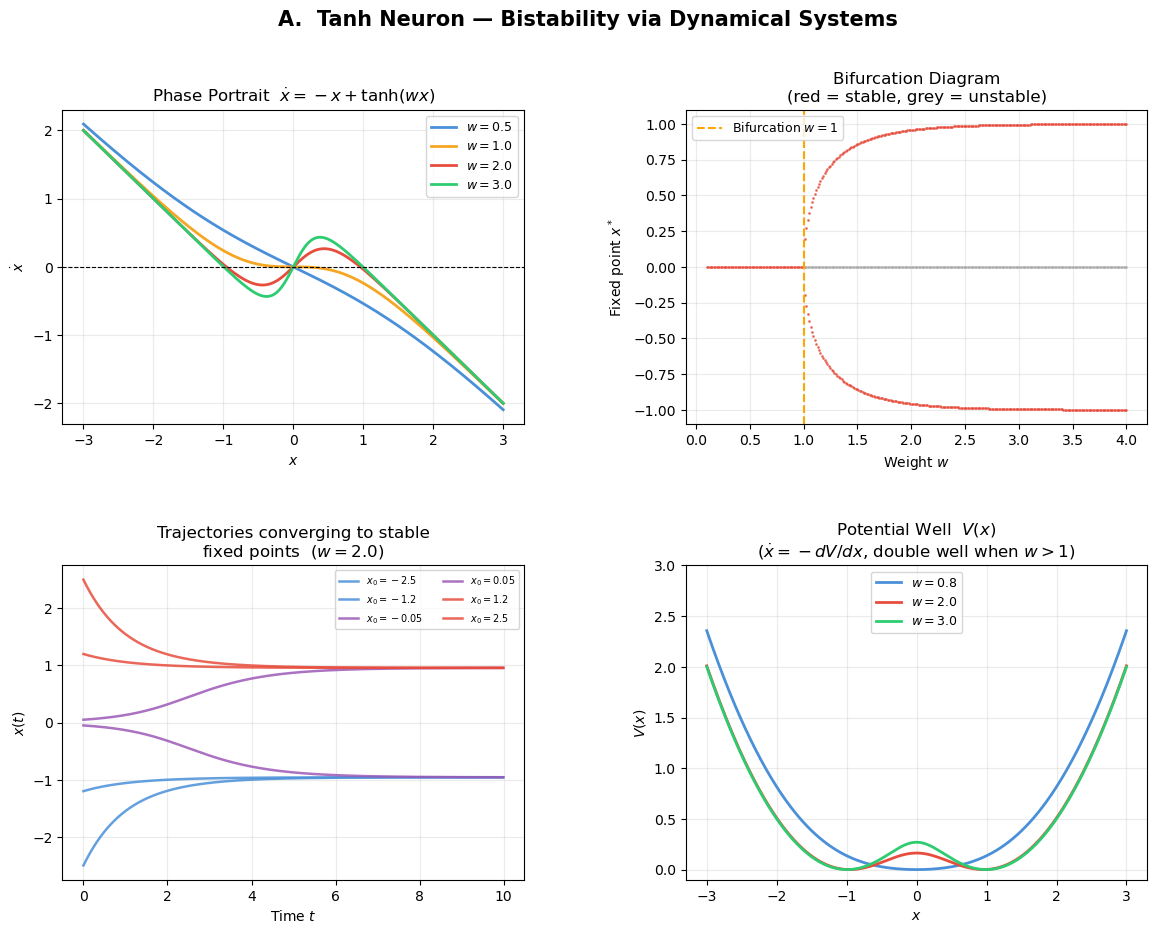

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
 
def f_tanh(x, w):
    """dx/dt = -x + tanh(w·x)"""
    return -x + np.tanh(w * x)
 
def euler(f, x0, t_end=10, dt=0.01):
    t = np.arange(0, t_end, dt)
    x = np.empty(len(t)); x[0] = x0
    for i in range(1, len(t)):
        x[i] = x[i-1] + f(x[i-1]) * dt
    return t, x
 
x_range  = np.linspace(-3, 3, 500)
w_values = [0.5, 1.0, 2.0, 3.0]
colors   = ["#4A90D9", "#F5A623", "#E74C3C", "#2ECC71"]
 
fig = plt.figure(figsize=(14, 10))
fig.suptitle("A.  Tanh Neuron — Bistability via Dynamical Systems",
             fontsize=15, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)
 
# Panel 1: Phase portrait
ax1 = fig.add_subplot(gs[0, 0])
for w, c in zip(w_values, colors):
    ax1.plot(x_range, f_tanh(x_range, w), color=c, lw=2, label=f"$w={w}$")
ax1.axhline(0, color="black", lw=0.8, ls="--")
ax1.set_title("Phase Portrait  $\\dot{x} = -x + \\tanh(wx)$")
ax1.set_xlabel("$x$"); ax1.set_ylabel("$\\dot{x}$")
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.25)
 
# Panel 2: Bifurcation diagram
ax2 = fig.add_subplot(gs[0, 1])
w_scan = np.linspace(0.1, 4.0, 300)
for w in w_scan:
    cands   = np.linspace(-3, 3, 1000)
    residual = cands - np.tanh(w * cands)
    for idx in np.where(np.diff(np.sign(residual)))[0]:
        xfp   = cands[idx] - residual[idx] * (
                cands[idx+1]-cands[idx]) / (residual[idx+1]-residual[idx])
        slope = -1 + w / np.cosh(w * xfp)**2
        ax2.plot(w, xfp, ".", color="#E74C3C" if slope < 0 else "#AAAAAA",
                 markersize=2, alpha=0.7)
ax2.axvline(1.0, color="orange", ls="--", lw=1.5, label="Bifurcation $w=1$")
ax2.set_title("Bifurcation Diagram\n(red = stable, grey = unstable)")
ax2.set_xlabel("Weight $w$"); ax2.set_ylabel("Fixed point $x^*$")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.25)
 
# Panel 3: Trajectories for w=2
ax3 = fig.add_subplot(gs[1, 0])
w = 2.0
for x0, c in zip([-2.5, -1.2, -0.05, 0.05, 1.2, 2.5],
                  ["#4A90D9","#4A90D9","#9B59B6","#9B59B6","#E74C3C","#E74C3C"]):
    t, x = euler(lambda x, w=w: f_tanh(x, w), x0)
    ax3.plot(t, x, color=c, lw=1.8, alpha=0.85, label=f"$x_0={x0}$")
ax3.set_title(f"Trajectories converging to stable\nfixed points  ($w={w}$)")
ax3.set_xlabel("Time $t$"); ax3.set_ylabel("$x(t)$")
ax3.legend(fontsize=7, ncol=2); ax3.grid(True, alpha=0.25)
 
# Panel 4: Potential wells V(x)
ax4 = fig.add_subplot(gs[1, 1])
for w, c in zip([0.8, 2.0, 3.0], ["#4A90D9", "#E74C3C", "#2ECC71"]):
    V = 0.5*x_range**2 - (1/w)*np.log(np.cosh(w*x_range))
    V -= V.min()
    ax4.plot(x_range, V, color=c, lw=2, label=f"$w={w}$")
ax4.set_title("Potential Well  $V(x)$\n($\\dot{{x}} = -dV/dx$, double well when $w>1$)")
ax4.set_xlabel("$x$"); ax4.set_ylabel("$V(x)$")
ax4.set_ylim(-0.1, 3.0)
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.25)
 
plt.savefig("A_tanh_bistability.png", dpi=150, bbox_inches="tight")
plt.show()


**What to observe:** For $w \leq 1$ there is a single potential well; the neuron is always off. For $w > 1$ the well splits into two — the neuron "locks" into whichever well it falls into. The bifurcation diagram shows this pitchfork split at exactly $w = 1$.

## B. State Space Models (SSMs / Mamba) — Memory Stability
 
### The Model
 
The core SSM hidden-state equation:
 
$$\dot{h}(t) = A\,h(t) + B\,u(t)$$
 
For a scalar system, the homogeneous solution is:
 
$$h(t) = e^{At}\,h(0)$$
 
### Stability Condition
 
The fixed point $h^* = 0$ has slope $f'(h^*) = A$:
 
$$A < 0 \;\Rightarrow\; \text{stable} \qquad A > 0 \;\Rightarrow\; \text{unstable}$$
 
| Eigenvalue | Behaviour | AI Consequence |
|---|---|---|
| $A \ll 0$ | Fast exponential decay | Short memory — forgets distant tokens |
| $A \approx 0^{-}$ | Slow decay | Long-range memory — retains context |
| $A > 0$ | Exponential growth | Hidden state **explodes** |
 
### Causal Link
 
Mamba's HiPPO matrix initialisation explicitly constrains all eigenvalues of $A$ to have negative real parts. This is the dynamical guarantee that the hidden state stays **bounded** across arbitrarily long sequences. Without it, the memory "fixed point" at $h^*=0$ becomes a repeller and the model breaks.


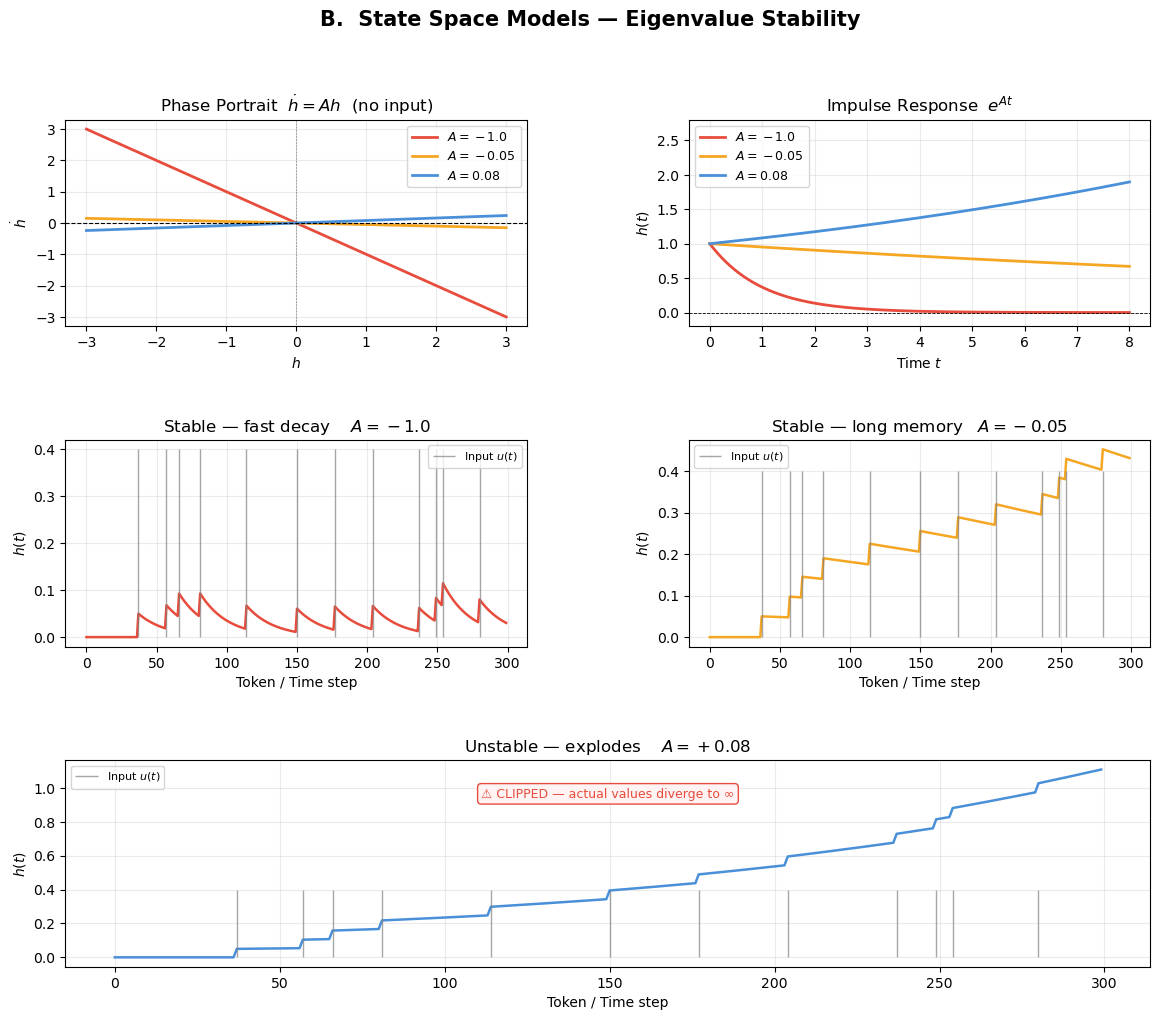

In [ ]:
#Eigenvalue Effect on Hidden State
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
 
def simulate_ssm(A, u_seq, dt=0.05):
    h, trace = 0.0, []
    for u in u_seq:
        h = h + (A * h + u) * dt
        trace.append(h)
    return np.array(trace)
 
np.random.seed(7)
T = 300
u = np.zeros(T)
u[np.random.choice(T, 12, replace=False)] = 1.0
 
configs = [
    (-1.0,  "#E74C3C", "Stable — fast decay    $A = -1.0$"),
    (-0.05, "#F5A623", "Stable — long memory   $A = -0.05$"),
    ( 0.08, "#4A90D9", "Unstable — explodes    $A = +0.08$"),
]
 
fig = plt.figure(figsize=(14, 11))
fig.suptitle("B.  State Space Models — Eigenvalue Stability",
             fontsize=15, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 2, hspace=0.55, wspace=0.35)
 
# Panel 1: Phase portrait dh/dt = A·h
ax1 = fig.add_subplot(gs[0, 0])
h_range = np.linspace(-3, 3, 300)
for A, c, lbl in configs:
    ax1.plot(h_range, A * h_range, color=c, lw=2, label=f"$A={A}$")
ax1.axhline(0, color="black", lw=0.8, ls="--")
ax1.axvline(0, color="black", lw=0.4, ls=":")
ax1.set_title("Phase Portrait  $\\dot{h} = Ah$  (no input)")
ax1.set_xlabel("$h$"); ax1.set_ylabel("$\\dot{h}$")
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.25)
 
# Panel 2: Impulse response e^{At}
ax2 = fig.add_subplot(gs[0, 1])
t_imp = np.linspace(0, 8, 400)
for A, c, lbl in configs:
    ax2.plot(t_imp, np.exp(A * t_imp), color=c, lw=2, label=f"$A={A}$")
ax2.axhline(0, color="black", lw=0.6, ls="--")
ax2.set_title("Impulse Response  $e^{At}$")
ax2.set_xlabel("Time $t$"); ax2.set_ylabel("$h(t)$")
ax2.set_ylim(-0.2, 2.8); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.25)
 
# Panels 3-5: Hidden state for each config
t_axis = np.arange(T)
ax_positions = [gs[1, 0], gs[1, 1], gs[2, :]]
for pos, (A, c, lbl) in zip(ax_positions, configs):
    ax = fig.add_subplot(pos)
    h  = np.clip(simulate_ssm(A, u), -30, 30)
    ax.plot(t_axis, h, color=c, lw=1.8)
    ax.vlines(np.where(u > 0)[0], 0, 0.4, color="gray", lw=1,
              alpha=0.7, label="Input $u(t)$")
    ax.set_title(lbl)
    ax.set_xlabel("Token / Time step"); ax.set_ylabel("$h(t)$")
    ax.grid(True, alpha=0.25); ax.legend(fontsize=8)
    if A > 0:
        ax.text(0.5, 0.82, "⚠ CLIPPED — actual values diverge to ∞",
                transform=ax.transAxes, ha="center", color="#E74C3C",
                fontsize=9, bbox=dict(boxstyle="round,pad=0.3",
                                      fc="#FFF3F3", ec="#E74C3C"))
 
plt.savefig("B_ssm_eigenvalues.png", dpi=150, bbox_inches="tight")
plt.show()

**What to observe:** $A = -1.0$ creates short memory (rapid decay to $h^*=0$). $A = -0.05$ creates long memory (slow decay — distant tokens still influence the hidden state). $A = +0.08$ destroys the fixed point — the memory explodes. This is why SSM design is fundamentally a stability problem.

## C. World Models — Contraction Mappings & Gradient Descent
 
### The Transition Model
 
The World Model latent transition:
 
$$\hat{s}_{t+1} = T(s_t,\, a_t)$$
 
For stable imagination rollouts, $T$ must be a **Contraction Mapping**:
 
$$\|T(s_1) - T(s_2)\| \leq k\,\|s_1 - s_2\|, \quad k < 1$$
 
The slope condition in 1D: $\left|\frac{dT}{ds}\right| < 1$ at the fixed point $s^*$.
 
### Gradient Descent as a Dynamical System
 
The continuous-time parameter update:
 
$$\dot{\theta} = -\nabla L(\theta)$$
 
Fixed points are critical points: $\nabla L(\theta^*) = 0$. Stability requires:
 
$$\frac{d}{d\theta}\bigl(-\nabla L\bigr)\bigg|_{\theta^*} = -\nabla^2 L(\theta^*) < 0 \quad \Leftrightarrow \quad \nabla^2 L(\theta^*) > 0$$
 
i.e., the **Hessian must be positive definite** — the loss must be locally convex at the minimum.
 
| System | Equation | Fixed Point | Slope Condition |
|---|---|---|---|
| World model rollout | $s_{t+1} = T(s_t)$ | True latent $s^*$ | $\|dT/ds\| < 1$ |
| Gradient descent | $\dot{\theta} = -\nabla L$ | Loss minimum $\theta^*$ | $\nabla^2 L > 0$ |
 
### Causal Link
 
If the World Model's transition is **not** a contraction ($k \geq 1$), small errors in $s_t$ amplify over the rollout horizon — imagined futures diverge from physical reality exponentially. DreamerV3 enforces this implicitly via KL-regularisation and bounded latent spaces.


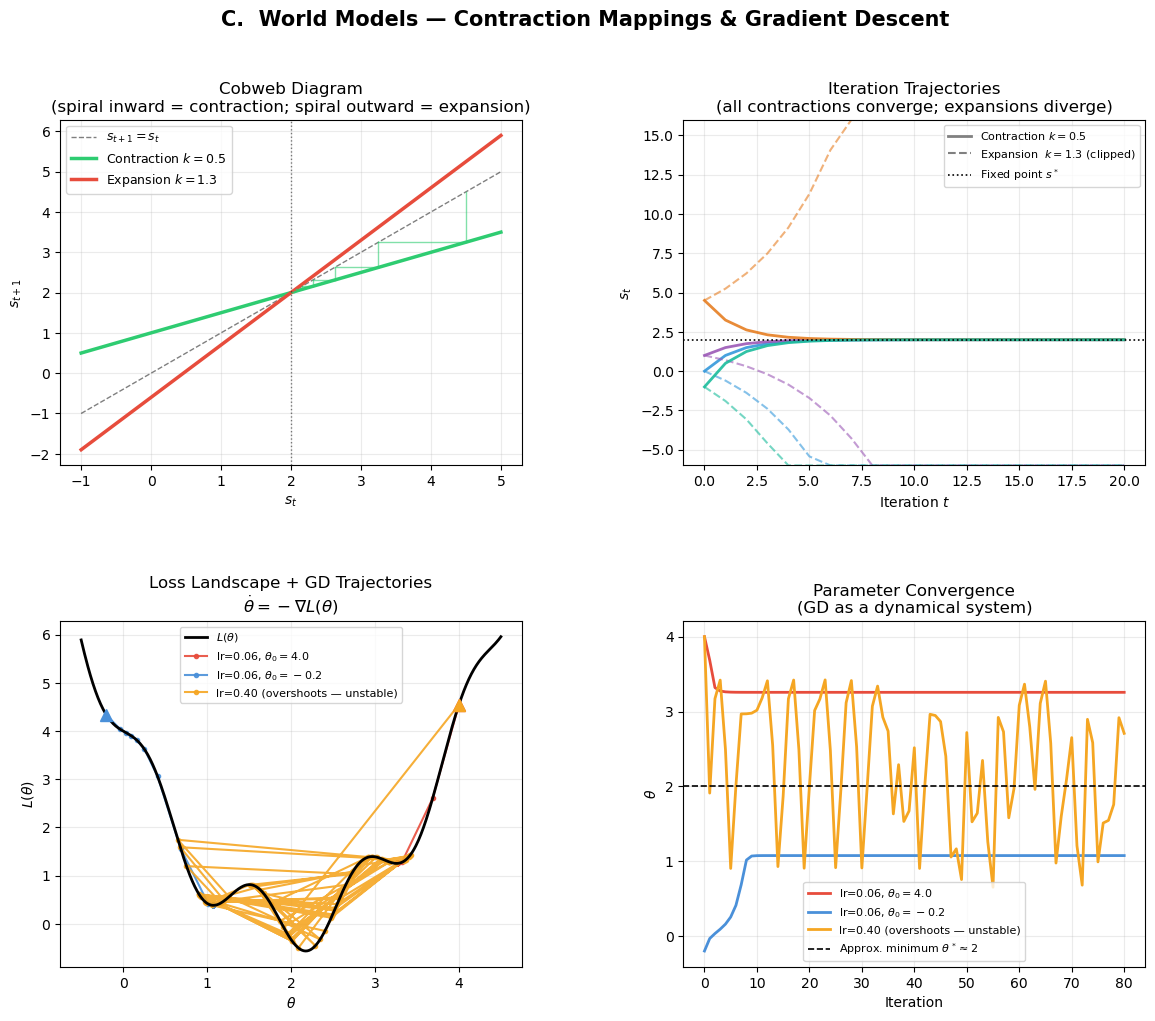

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
 
# ── World model maps ──────────────────────────────────────────────
def T_contract(s, k=0.5, s_star=2.0):
    return s_star + k * (s - s_star)
 
def T_expand(s, k=1.3, s_star=2.0):
    return s_star + k * (s - s_star)
 
# ── Loss landscape ────────────────────────────────────────────────
def loss(theta):
    return (theta - 2)**2 + 0.6 * np.sin(5 * theta)
 
def grad_L(theta):
    return 2*(theta - 2) + 3.0 * np.cos(5 * theta)
 
def gd(theta0, lr, steps=80):
    traj = [theta0]
    for _ in range(steps):
        traj.append(traj[-1] - lr * grad_L(traj[-1]))
    return np.array(traj)
 
fig = plt.figure(figsize=(14, 11))
fig.suptitle("C.  World Models — Contraction Mappings & Gradient Descent",
             fontsize=15, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)
 
# Panel 1: Cobweb diagram
ax1 = fig.add_subplot(gs[0, 0])
s_range = np.linspace(-1, 5, 300)
ax1.plot(s_range, s_range,              "k--",     lw=1,   alpha=0.5, label="$s_{t+1}=s_t$")
ax1.plot(s_range, T_contract(s_range),  "#2ECC71", lw=2.5, label="Contraction $k=0.5$")
ax1.plot(s_range, T_expand(s_range),    "#E74C3C",  lw=2.5, label="Expansion $k=1.3$")
s = 4.5
for _ in range(10):
    s_next = T_contract(s)
    ax1.plot([s, s],        [s, s_next],     "#2ECC71", lw=1, alpha=0.6)
    ax1.plot([s, s_next],   [s_next, s_next],"#2ECC71", lw=1, alpha=0.6)
    s = s_next
ax1.axvline(2.0, color="black", ls=":", lw=1, alpha=0.5)
ax1.set_title("Cobweb Diagram\n(spiral inward = contraction; spiral outward = expansion)")
ax1.set_xlabel("$s_t$"); ax1.set_ylabel("$s_{t+1}$")
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.25)
 
# Panel 2: Iteration trajectories
ax2 = fig.add_subplot(gs[0, 1])
iters = 20
start_colors = ["#3498DB","#9B59B6","#E67E22","#1ABC9C"]
for s0, c in zip([0.0, 1.0, 4.5, -1.0], start_colors):
    sc = [s0]; se = [s0]
    for _ in range(iters):
        sc.append(T_contract(sc[-1])); se.append(T_expand(se[-1]))
    ax2.plot(sc, color=c, lw=2,   alpha=0.9)
    ax2.plot(np.clip(se, -6, 16), color=c, lw=1.5, ls="--", alpha=0.6)
ax2.axhline(2.0, color="black", ls=":", lw=1.2, label="Fixed point $s^*=2$")
ax2.legend(handles=[
    Line2D([0],[0], color="gray", lw=2,          label="Contraction $k=0.5$"),
    Line2D([0],[0], color="gray", lw=1.5, ls="--",label="Expansion  $k=1.3$ (clipped)"),
    Line2D([0],[0], color="black",lw=1.2, ls=":", label="Fixed point $s^*$"),
], fontsize=8)
ax2.set_title("Iteration Trajectories\n(all contractions converge; expansions diverge)")
ax2.set_xlabel("Iteration $t$"); ax2.set_ylabel("$s_t$")
ax2.set_ylim(-6, 16); ax2.grid(True, alpha=0.25)
 
# Panel 3: Loss landscape
ax3 = fig.add_subplot(gs[1, 0])
theta_r = np.linspace(-0.5, 4.5, 500)
ax3.plot(theta_r, loss(theta_r), "k-", lw=2, label="$L(\\theta)$", zorder=5)
gd_configs = [
    (4.0,  0.06, "#E74C3C", "lr=0.06, $\\theta_0=4.0$"),
    (-0.2, 0.06, "#4A90D9", "lr=0.06, $\\theta_0=-0.2$"),
    (4.0,  0.40, "#F5A623", "lr=0.40 (overshoots — unstable)"),
]
for theta0, lr, c, lbl in gd_configs:
    traj = gd(theta0, lr)
    ax3.plot(traj, loss(traj), "o-", color=c, markersize=3,
             lw=1.5, alpha=0.9, label=lbl, zorder=4)
    ax3.plot(traj[0], loss(traj[0]), "^", color=c, markersize=9, zorder=6)
ax3.set_title("Loss Landscape + GD Trajectories\n$\\dot{{\\theta}} = -\\nabla L(\\theta)$")
ax3.set_xlabel("$\\theta$"); ax3.set_ylabel("$L(\\theta)$")
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.25)
 
# Panel 4: Convergence curves
ax4 = fig.add_subplot(gs[1, 1])
iters_gd = np.arange(81)
for theta0, lr, c, lbl in gd_configs:
    ax4.plot(iters_gd, gd(theta0, lr), color=c, lw=2, label=lbl)
ax4.axhline(2.0, color="black", ls="--", lw=1.2,
            label="Approx. minimum $\\theta^* \\approx 2$")
ax4.set_title("Parameter Convergence\n(GD as a dynamical system)")
ax4.set_xlabel("Iteration"); ax4.set_ylabel("$\\theta$")
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.25)
 
plt.savefig("C_world_models_contraction.png", dpi=150, bbox_inches="tight")
plt.show()

> **What to observe:** The cobweb spirals inward (contraction, $k=0.5$) or outward (expansion, $k=1.3$) — this is the exact same stability split as in the Tanh neuron and SSM. In GD: low learning rate ($0.06$) satisfies the contraction condition and converges; high learning rate ($0.40$) violates it and oscillates. The minimum of $L$ is the stable fixed point; the saddle points are unstable ones.
 
---
 
## Unified Summary
 
| AI System | Dynamical Equation | Fixed Point | Stability Condition |
|---|---|---|---|
| **Tanh Neuron** | $\dot{x} = -x + \tanh(wx)$ | $x^* = \pm x_{\text{stable}}$ | $f'(x^*) = -1 + w\,\text{sech}^2(wx^*) < 0$ |
| **SSM / Mamba** | $\dot{h} = Ah + Bu$ | $h^* = 0$ | $\text{Re}(\lambda_A) < 0$ |
| **Gradient Descent** | $\dot{\theta} = -\nabla L(\theta)$ | $\theta^*$ = loss minimum | $\nabla^2 L(\theta^*) \succ 0$ |
| **World Model** | $s_{t+1} = T(s_t, a_t)$ | $s^*$ = true latent state | $\|dT/ds\| < 1$ (contraction) |
 
> **The unifying principle:** In every case, stability = negative slope at the fixed point. Whether it is a Tanh neuron locking into a decision, an SSM retaining bounded memory, a loss landscape attracting gradient descent, or a world model converging on reality — the mathematics is identical. Dynamical systems theory is the hidden backbone of modern AI.